In [ ]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot



In [2]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
print(data)

[[ 1.850e+03 -4.360e-01  1.700e-01 ...  1.560e-01        nan        nan]
 [ 1.851e+03 -3.210e-01  2.590e-01 ...  2.250e-01        nan        nan]
 [ 1.852e+03 -2.920e-01  2.490e-01 ...  2.170e-01 -3.160e-01  1.530e-01]
 ...
 [ 2.022e+03  9.360e-01  3.100e-02 ...  2.800e-02  9.580e-01  2.200e-02]
 [ 2.023e+03  1.229e+00  3.100e-02 ...  2.800e-02        nan        nan]
 [ 2.024e+03  1.311e+00  3.200e-02 ...  2.700e-02        nan        nan]]


In [3]:
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)


print(df[:-5])

     year  annual_anomaly_above  annual_unc_above  five_year_anomaly_above  \
0    1850                -0.436             0.170                      NaN   
1    1851                -0.321             0.259                      NaN   
2    1852                -0.292             0.249                   -0.325   
3    1853                -0.295             0.196                   -0.294   
4    1854                -0.283             0.130                   -0.309   
..    ...                   ...               ...                      ...   
165  2015                 0.923             0.027                    0.885   
166  2016                 1.059             0.027                    0.922   
167  2017                 0.962             0.026                    0.971   
168  2018                 0.888             0.028                    0.996   
169  2019                 1.024             0.031                    0.964   

     five_year_unc_above  annual_anomaly_below  annual_unc_belo

In [4]:
yerr_above = df["annual_unc_above"] / 2.
yerr_below = df["annual_unc_below"] / 2.

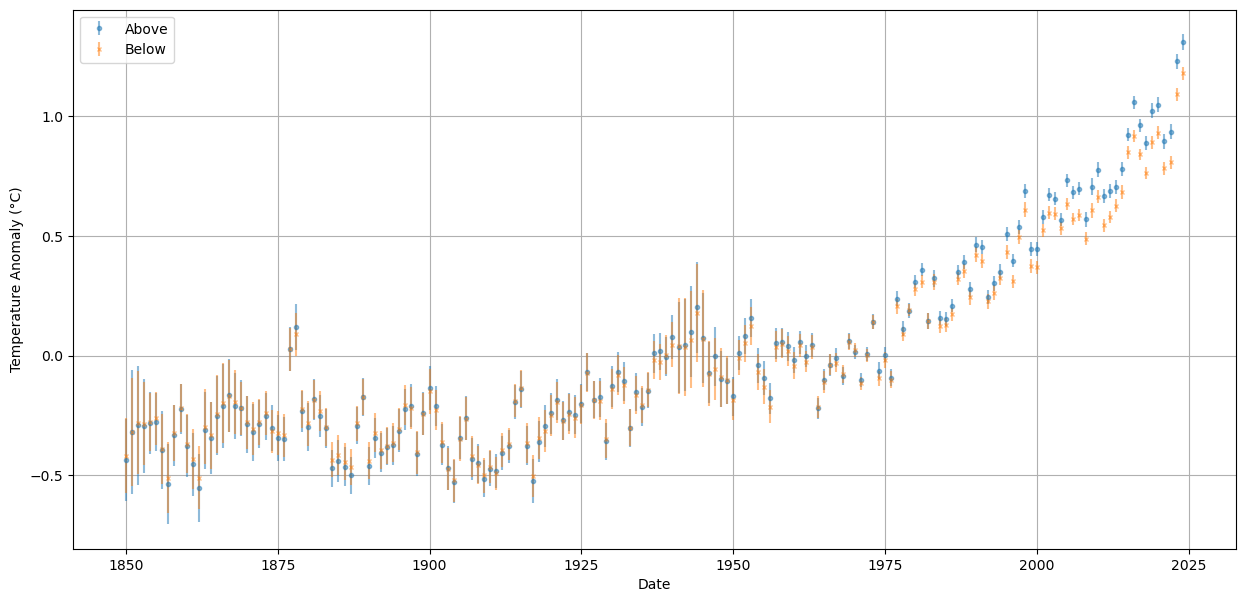

In [6]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.errorbar(df["year"], df["annual_anomaly_below"], yerr=df["annual_unc_below"], fmt="x", markersize=3, label="Below", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [7]:
# convert to np arrays for easier ingestion for ultranest
date = df["year"].values
temp_anomaly = df["annual_anomaly_above"].values


In [10]:
def constant_model(q):
    return q 

def constant_prior(cube):
    params = cube.copy()

    lower_bound = -10.0
    upper_bound = 10.0

    params[0] = lower_bound + cube[0] * (upper_bound - lower_bound)

    return params

def log_likelihood(params):
    q = params[0]
    model = constant_model(q)
    log_likelihood_value = -0.5 * ((temp_anomaly - model) ** 2 / yerr_above ** 2).sum()

    return log_likelihood_value

parameters = ["q"]

In [11]:
sampler = ultranest.ReactiveNestedSampler(
    parameters, log_likelihood, constant_prior
)
result = sampler.run()
print(result)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+04  -29145.77 [-29145.7707..-29145.7707]*| it/evals=4640/5181 eff=97.0508% N=400 0 0 0  
[ultranest] Likelihood function evaluations: 5195
[ultranest]   logZ = -2.915e+04 +- 0.1166
[ultranest] Effective samples strategy satisfied (ESS = 1241.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.12 tail:0.04 total:0.12 required:<0.50
[ultranest] done iterating.
{'niter': 5054, 'logz': np.float64(-29154.15693326912), 'logzerr': np.float64(0.3211449141285041), 'logz_bs': np.float64(-29154.161588849474), 'logz_single': np.float64(-29154.15693326912), 'logzerr_tail': np.float64(0.03811561568363686), 'logzerr_bs': np.float64(0.31887498445576057), 'ess': np.float64(1241.8068145255784), 'H': np.float64(7.920781423312292), 'Herr': np.float64(0.11100660426284634), 'posterior': {'mean

/home/steve/projects/lab-dati-02/.conda/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


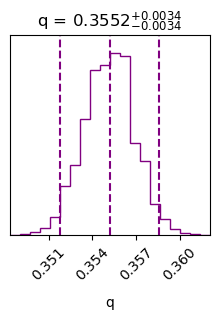

In [ ]:
cornerplot(
    result,
    title_fmt=".4f",
    quantiles=[0.025, 0.5, 0.975]
)
plt.show()

In [13]:
print(result["posterior"])

{'mean': [0.3551438391532791], 'stdev': [0.0017248275006653806], 'median': [0.3551755791073967], 'errlo': [0.35336892342962223], 'errup': [0.35677539093454413], 'information_gain_bits': [4.14647919764959]}


In [14]:
print(result["samples"])

[[0.35309817]
 [0.3582862 ]
 [0.35660797]
 ...
 [0.35405147]
 [0.35383206]
 [0.35494995]]


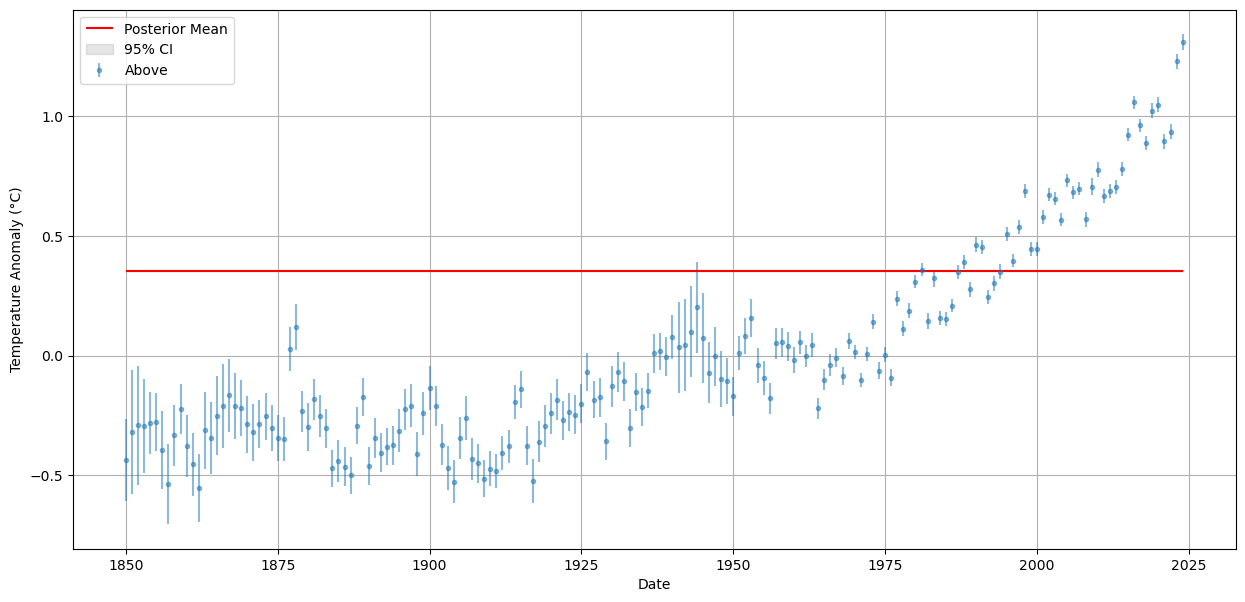

In [16]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.hlines(result["posterior"]["mean"], df["year"].min(), df["year"].max(), color="red", label="Posterior Mean")
q_samples = result["samples"][:, 0]
ci_low, ci_high = np.percentile(q_samples, [2.5, 97.5])

plt.fill_between(
    [df["year"].min(), df["year"].max()],
    ci_low,
    ci_high,
    color="gray",
    alpha=0.2,
    label="95% CI",
)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [19]:
def linear_model(x, q, m):
    return q + m*x

def linear_prior(cube):
    params = cube.copy()

    lo_0 = -2000.0
    hi_0 = 2000.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -5.
    hi_1 = 5.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params

def log_linear_likelihood(params):
    q = params[0]
    m = params[1]
    model = linear_model(date, q, m)
    log_likelihood_value = -0.5 * ((temp_anomaly - model) ** 2 / yerr_above ** 2).sum()

    return log_likelihood_value

parameters_linear = ["q", "m"]

In [20]:
sampler_linear = ultranest.ReactiveNestedSampler(
    parameters_linear, log_linear_likelihood, linear_prior
)
result_linear = sampler_linear.run()
print(result_linear)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+03  915.43 [-6915.4396..-6915.4396]*| it/evals=12120/16610 eff=74.7687% N=400        0   0   
[ultranest] Likelihood function evaluations: 16642
[ultranest]   logZ = -6941 +- 0.1972
[ultranest] Effective samples strategy satisfied (ESS = 1638.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.
{'niter': 12544, 'logz': np.float64(-6941.189124205545), 'logzerr': np.float64(0.37954976485236563), 'logz_bs': np.float64(-6941.150147250473), 'logz_single': np.float64(-6941.189124205545), 'logzerr_tail': np.float64(0.009946536963070685), 'logzerr_bs': np.float64(0.3794194122629051), 'ess': np.float64(1638.89154168691), 'H': np.float64(24.721665910618867), 'Herr': np.float64(0.1909181154899498), 'posterior': {'mean

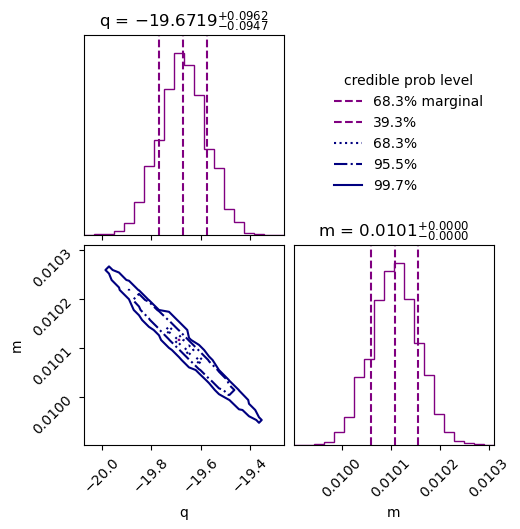

In [21]:
cornerplot(
    result_linear,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

In [22]:
print(result_linear["posterior"])
print(result_linear["samples"])

{'mean': [-19.670354176201812, 0.01010816183010146], 'stdev': [0.09603257775427151, 4.8497413449023376e-05], 'median': [-19.67194407038096, 0.010108871226836236], 'errlo': [-19.766863192941855, 0.010060642435271383], 'errup': [-19.575549163727374, 0.010156736609291173], 'information_gain_bits': [4.14647919764959, 4.14647919764959]}
[[-1.96530555e+01  1.00996092e-02]
 [-1.96251941e+01  1.00850876e-02]
 [-1.96200822e+01  1.00832808e-02]
 ...
 [-1.97688142e+01  1.01558083e-02]
 [-1.95508487e+01  1.00487512e-02]
 [-1.96979117e+01  1.01211784e-02]]


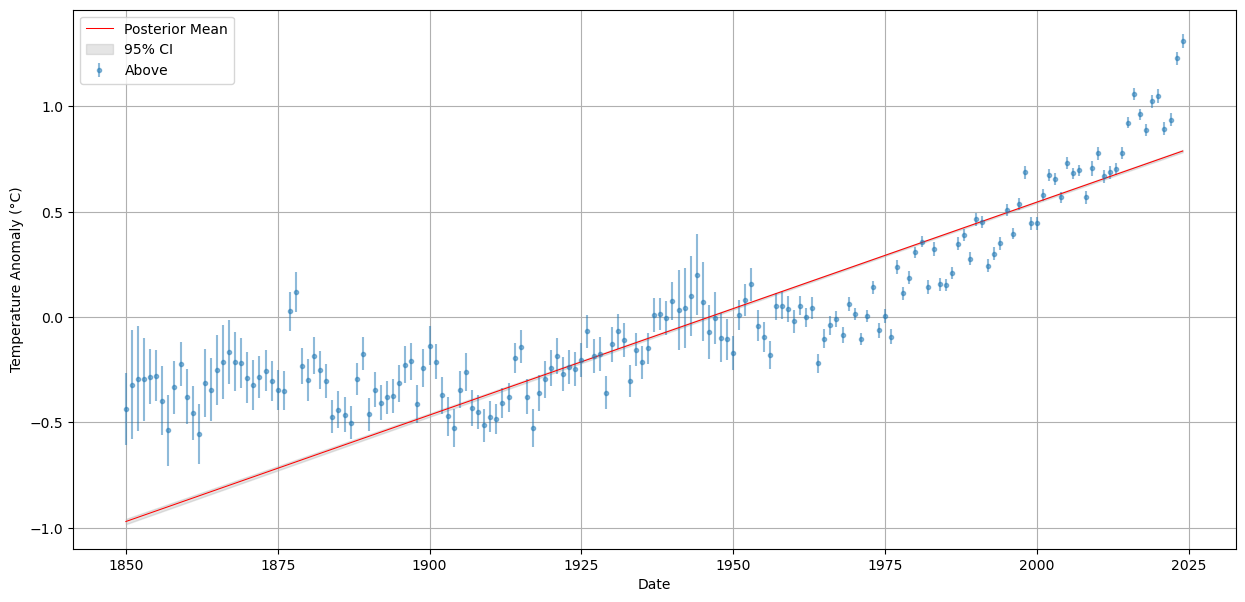

In [29]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min(), df["year"].max(), 100)
band = PredictionBand(year_range)

for params in result_linear["samples"]:
    q, m = params
    band.add(linear_model(year_range, q, m))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [31]:
def exponential_model(x, q, a, m):
    # Rescale time to avoid overflow in exp for calendar-year inputs.
    t = (x - 1950.0) / 50.0
    #exponent = np.clip(m * t, -50.0, 50.0)
    return q + a * np.exp(m * t)


def exponential_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    return params


def log_exponential_likelihood(params):
    q, a, m = params
    model = exponential_model(date, q, a, m)

    if not np.all(np.isfinite(model)):
        return -1e300

    resid = temp_anomaly - model
    variance = np.asarray(yerr_above) ** 2

    if np.any(variance <= 0) or not np.all(np.isfinite(variance)):
        return -1e300

    log_likelihood_value = -0.5 * np.sum((resid ** 2) / variance)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_exponential = ["q", "a", "m"]

In [32]:
sampler_exponential = ultranest.ReactiveNestedSampler(
    parameters_exponential, log_exponential_likelihood, exponential_prior
)
result_exponential = sampler_exponential.run()
print(result_exponential)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+03  821.80 [-1821.8613..-1821.8610]*| it/evals=9630/47842 eff=20.2985% N=400    0  0 
[ultranest] Likelihood function evaluations: 47856
[ultranest]   logZ = -1841 +- 0.1813
[ultranest] Effective samples strategy satisfied (ESS = 1900.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.
{'niter': 10037, 'logz': np.float64(-1841.3222800012984), 'logzerr': np.float64(0.43615745137440504), 'logz_bs': np.float64(-1841.2998212552295), 'logz_single': np.float64(-1841.3222800012984), 'logzerr_tail': np.float64(0.009928643412195015), 'logzerr_bs': np.float64(0.4360444294213721), 'ess': np.float64(1900.143611522892), 'H': np.float64(18.009301353112733), 'Herr': np.float64(0.17259554644134548), 'posterior': {'mean': 

In [34]:
df_results = pd.DataFrame(result_exponential["samples"], columns=parameters_exponential)
df_results.describe()

,q,a,m
count,10037.000000,10037.000000,10037.000000
mean,-0.410895,0.303456,1.114301
std,0.007699,0.006742,0.013319
min,-0.440465,0.279229,1.064458
25%,-0.416005,0.298874,1.105358
50%,-0.410809,0.303409,1.114283
75%,-0.405530,0.307911,1.123087
max,-0.381854,0.329953,1.162773


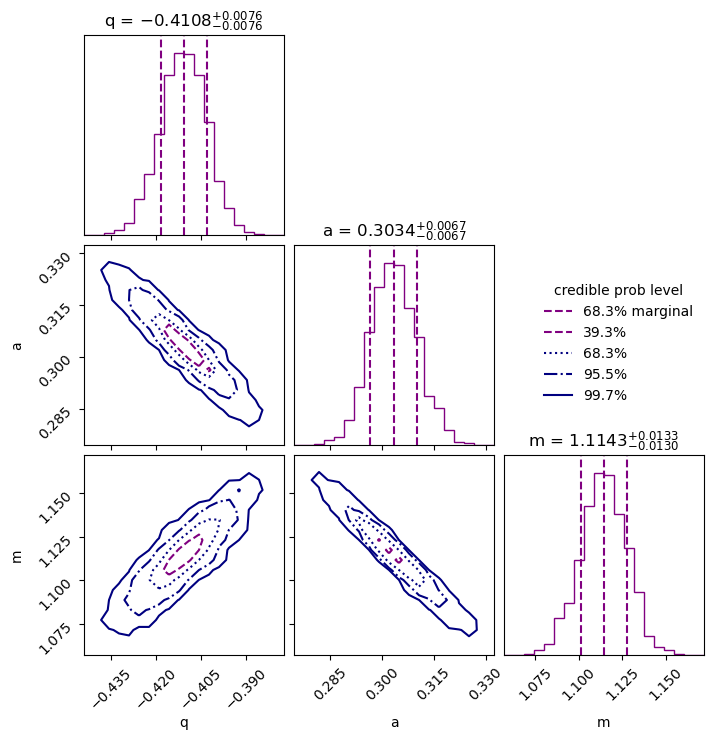

In [35]:
cornerplot(
    result_exponential,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

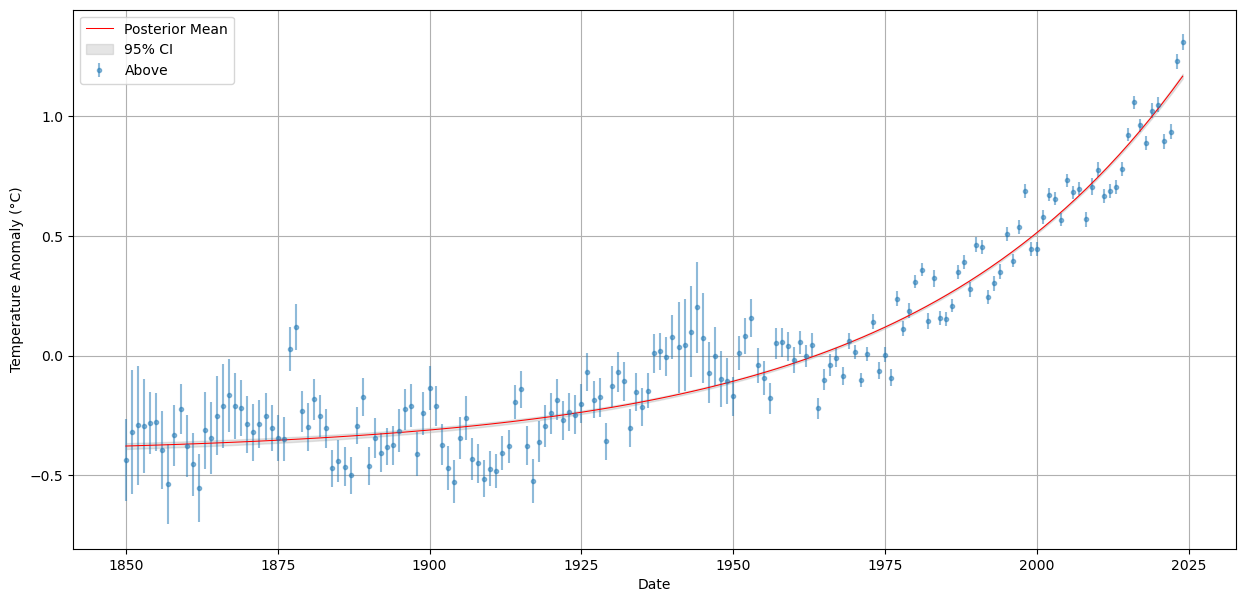

In [36]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min(), df["year"].max(), 100)
band = PredictionBand(year_range)

for params in result_exponential["samples"]:
    q, a, m = params
    band.add(exponential_model(year_range, q, a, m))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()